<a href="https://colab.research.google.com/github/ahammadmejbah/Scikit-Learn-With-Mathematics-and-Python-By-Mejbah-Ahammad/blob/main/Lecture%2011%3A%20Lazy%20Learning%20and%20Egar%20Learning%20in%20Fit%20Method/Lecture_11_Lazy_Learners_vs_Eager_Learners_in_fit().ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lecture 11: Lazy Learners vs. Eager Learners in `.fit()`

## 1. Definitions and Core Philosophies

In [ ]:
import time

def timmer(funtions, *args, **kwargs):
    start = time.time()
    outcome = funtions(*args, **kwargs)
    end = time.time()
    return outcome, end - start

In [ ]:
def numbers(*args):
    print(args)

numbers(1, 2, 3, 4, 5)

(1, 2, 3, 4, 5)


In [ ]:
def numbers(**kwargs):
    print(kwargs)

numbers(name="Mejbah Ahammad", ContactNumber = 1874603631)

{'name': 'Mejbah Ahammad', 'ContactNumber': 1874603631}


### 1.1 Eager Learner: Learns during `.fit()`

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Capital X- Input Matrix and Small x - Input Vector and y - Output/Target Vector

X = np.random.rand(1000000, 1)
y = 3* X.flatten() + 5

In [ ]:
X

array([[0.55970478],
       [0.85241782],
       [0.49374044],
       ...,
       [0.04312081],
       [0.08883078],
       [0.34861682]])

In [ ]:
y

array([6.67911433, 7.55725347, 6.48122131, ..., 5.12936243, 5.26649234,
       6.04585046])

In [ ]:
model  = LinearRegression()
_, time_to_fit = timmer(model.fit, X, y)
print(time_to_fit)

0.08215951919555664


### 1.2 Lazy Learner: Defers learning to `.predict()`

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
knn_Model  = KNeighborsRegressor(n_neighbors = 5)
_, time_to_knn__fit = timmer(knn_Model.fit, X, y)
print(time_to_knn__fit)

0.6229503154754639


### 1.3 Training vs Prediction Time (Measured)

In [ ]:
#model.predict
_, egar_learning_predict = timmer(model.predict, X[:100])
_, lazy_learning_predict =timmer(knn_Model.predict,X[:100])
print(f"Time for Egar learning is : {egar_learning_predict}\nTime for Lazy Learning: {lazy_learning_predict}")

Time for Egar learning is : 0.0004391670227050781
Time for Lazy Learning: 0.0029060840606689453


## 2. Eager Learners: Heavy `.fit()`

In [ ]:
print(f"Model Coeff: {model.coef_}\nModel intercept: {model.intercept_}")

Model Coeff: [3.]
Model intercept: 5.0


In [ ]:
hasattr(model, "X_")

False

In [ ]:
hasattr(model, "y_")

False

### Decision Tree as Eager Learner

In [ ]:
from sklearn.tree import DecisionTreeClassifier

X_classifier = np.random.rand(10000, 2)
#print(f"This is for 0 Class: {X_classifier[:,0]}")
#print(f"\nThis is for 1 Class: {X_classifier[:,1]}")
y_classifier = (X_classifier[:,0] + X_classifier[:,1] >1).astype('int')
#print(f"\nThis is for output Class: {y_classifier}")

tree_model = DecisionTreeClassifier(max_depth = 3)
tree_model.fit(X_classifier, y_classifier)

DecisionTreeClassifier(max_depth=3)

In [ ]:
tree_model.feature_importances_

array([0.50367129, 0.49632871])

## 3. Lazy Learners: Heavy `.predict()`

In [ ]:
knn_Model._fit_X[:5]

array([[0.55970478],
       [0.85241782],
       [0.49374044],
       [0.14180231],
       [0.40301115]])

In [ ]:
knn_Model._y[:5]

array([6.67911433, 7.55725347, 6.48122131, 5.42540693, 6.20903346])

In [ ]:
from sklearn.metrics import pairwise_distances
pairwise_distances(X[:5], knn_Model._fit_X[:5])

array([[0.        , 0.29271305, 0.06596434, 0.41790246, 0.15669362],
       [0.29271305, 0.        , 0.35867739, 0.71061551, 0.44940667],
       [0.06596434, 0.35867739, 0.        , 0.35193812, 0.09072928],
       [0.41790246, 0.71061551, 0.35193812, 0.        , 0.26120884],
       [0.15669362, 0.44940667, 0.09072928, 0.26120884, 0.        ]])

## 4. Comparative Analysis with Code

In [ ]:
import sys
print(f"Model Size of Lineaer Regression: {sys.getsizeof(model)}")
print(f"Model Size of KNN Model: {sys.getsizeof(knn_Model)}")
print(f"Model Size of Tree: {sys.getsizeof(tree_model)}")

Model Size of Lineaer Regression: 48
Model Size of KNN Model: 48
Model Size of Tree: 48


In [ ]:
big_datasets_for_x = np.random.rand(5000000, 1)
big_datasets_for_y = big_datasets_for_x.flatten()

In [ ]:
linear_model_for_bigData = LinearRegression()
knn_model_for_bigData = KNeighborsRegressor()

_, linearegar_big = timmer(linear_model_for_bigData.fit,big_datasets_for_x, big_datasets_for_y)
_, knn_lazy_big = timmer(knn_model_for_bigData.fit,big_datasets_for_x, big_datasets_for_y)


print(f"Time for Egar learning is : {linearegar_big}\nTime for Lazy Learning: {knn_lazy_big}")

Time for Egar learning is : 0.40792226791381836
Time for Lazy Learning: 5.9923460483551025


In [ ]:
_, linearegar_big_predict = timmer(linear_model_for_bigData.predict,big_datasets_for_x[:100])
_, knn_lazy_big_predict = timmer(knn_model_for_bigData.predict,big_datasets_for_x[:100])


print(f"Time for Egar learning is : {linearegar_big_predict}\nTime for Lazy Learning: {knn_lazy_big_predict}")

Time for Egar learning is : 0.0003325939178466797
Time for Lazy Learning: 0.0028829574584960938


## 5. Visualizing `.fit()` vs `.predict()` Cost

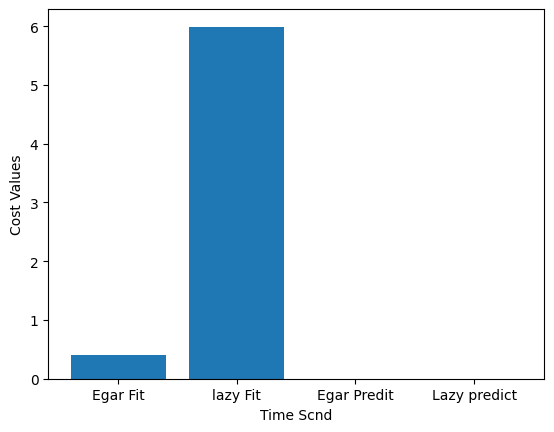

In [ ]:
import matplotlib.pyplot as plt

labels = ["Egar Fit", "lazy Fit", "Egar Predit", "Lazy predict"]
values = [linearegar_big, knn_lazy_big, linearegar_big_predict, knn_lazy_big_predict]
plt.bar(labels, values)
plt.xlabel("Time Scnd")
plt.ylabel("Cost Values")
plt.show()

## 6. Practical Decision via Code

In [ ]:
for data_size in [10, 100, 1000, 10000, 100000, 1000000]:
    _, t1 = timmer(linear_model_for_bigData.predict,big_datasets_for_x[:data_size])
    _, t2 = timmer(knn_model_for_bigData.predict,big_datasets_for_x[:data_size])
    print(f"Batch {data_size}: Egar learning: {t1:.3f}s, Lazy Learning: {t2:.3f}s")

Batch 10: Egar learning: 0.000s, Lazy Learning: 0.001s
Batch 100: Egar learning: 0.000s, Lazy Learning: 0.002s
Batch 1000: Egar learning: 0.000s, Lazy Learning: 0.010s
Batch 10000: Egar learning: 0.001s, Lazy Learning: 0.066s
Batch 100000: Egar learning: 0.001s, Lazy Learning: 0.600s
Batch 1000000: Egar learning: 0.008s, Lazy Learning: 6.728s



## Final Code-Based Conclusion

- Eager Learners **pay cost once in `.fit()`**
- Lazy Learners **pay cost every time in `.predict()`**
- Code evidence matches theory exactly
